# F2 - Obtención, limpieza y transformación de datos

## Análisis global de la industria fitness y gimnasios 2000-2026

Este notebook corresponde a la **Fase 2** del proyecto ABP del curso **MCDI500 — Herramientas de software científico**.

La Fase 2 se centra en la construcción de un pipeline reproducible de datos, incorporando obtención/carga del dataset, diagnóstico inicial, limpieza, depuración, transformación, validación técnica y exportación del dataset procesado.

El trabajo se desarrolla sobre el archivo original:

```text
data/raw/clean_gym_data.csv
```

y genera como salida un archivo procesado en:

```text
data/processed/gym_data_processed.csv
```

> Este notebook debe ejecutarse dentro del entorno reproducible configurado en Fase 1 y mantenerse integrado al repositorio GitHub.

## Integrantes

- Wilson Arévalo
- Luis Espinosa
- Mauricio Ortega
- Eduardo Garrido

## Resumen ejecutivo de Fase 2

La Fase 2 tiene como propósito implementar el notebook de obtención, limpieza y transformación de datos del proyecto. A diferencia de la Fase 1, que se enfocó en la definición del problema, la estructura del repositorio y la exploración inicial, esta etapa implementa un pipeline técnico para preparar el dataset antes de los análisis posteriores.

El notebook incluye:

- Carga reproducible del dataset original.
- Validación de estructura y columnas esperadas.
- Diagnóstico de calidad de datos.
- Implementación de funciones auxiliares.
- Revisión de valores nulos y duplicados.
- Conversión de tipos de datos.
- Validación de rangos esperados.
- Transformación de variables.
- Creación de variables derivadas.
- Normalización de variables seleccionadas.
- Validación del dataset procesado.
- Comparación antes/después.
- Exportación del archivo procesado.
- Bitácora de transformaciones y decisiones técnicas.

El objetivo es asegurar que el dataset quede preparado de forma trazable, documentada y reproducible para las siguientes fases del proyecto.

## Relación con Fase 1

En la Fase 1 se estableció la base conceptual, técnica y reproducible del proyecto. Se definió la problemática, se identificaron variables principales, se configuró la estructura del repositorio, se documentó el flujo reproducible y se validó la carga inicial del dataset.

La Fase 2 toma esa base y avanza hacia el procesamiento real del dataset. Por ello, este notebook no reemplaza a `F1_Definicion_v2.ipynb`, sino que lo complementa.

| Fase | Enfoque | Producto principal |
|---|---|---|
| Fase 1 | Definición, estructura, documentación inicial y reproducibilidad | `F1_Definicion_v2.ipynb` |
| Fase 2 | Obtención, limpieza, depuración, transformación y validación de datos | `F2_Limpieza_Transformacion.ipynb` |

## Objetivo general de Fase 2

Implementar un pipeline reproducible de obtención, limpieza, depuración, transformación y validación del dataset `clean_gym_data.csv`, utilizando Python y librerías del ecosistema científico, para preparar una versión procesada y técnicamente consistente de los datos que permita continuar con las fases posteriores del análisis.

## Objetivos específicos de Fase 2

- Cargar el dataset original desde una ruta relativa reproducible.
- Validar la existencia del archivo y la estructura esperada del repositorio.
- Verificar la presencia de columnas principales.
- Diagnosticar tipos de datos, valores nulos, duplicados y rangos numéricos.
- Implementar funciones modulares para separar tareas del pipeline.
- Aplicar casting de variables para asegurar consistencia técnica.
- Depurar registros duplicados si existen.
- Tratar valores nulos bajo criterios explícitos y trazables.
- Crear variables derivadas útiles para análisis posteriores.
- Normalizar variables numéricas seleccionadas.
- Validar el dataset resultante luego del procesamiento.
- Exportar el dataset procesado a `data/processed/`.
- Documentar decisiones metodológicas y técnicas del proceso.

## Descripción del pipeline de datos

El pipeline de Fase 2 se organiza en las siguientes etapas:

```text
Carga del dataset original
        ↓
Copia de trabajo
        ↓
Diagnóstico inicial
        ↓
Validación de columnas esperadas
        ↓
Limpieza y estandarización
        ↓
Casting de tipos de datos
        ↓
Tratamiento de nulos y duplicados
        ↓
Validación de rangos
        ↓
Transformación de variables
        ↓
Creación de variables derivadas
        ↓
Normalización
        ↓
Validación del dataset procesado
        ↓
Exportación a data/processed/
```

Este pipeline busca asegurar que cada paso sea explícito, reproducible y verificable.

## Carga de librerías

Se cargan las librerías necesarias para el procesamiento de datos. Se utilizan principalmente `pandas` y `numpy`, junto con `matplotlib` para visualizaciones de control y `pathlib` para rutas reproducibles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## Configuración de rutas reproducibles

Las rutas se definen de forma relativa porque el notebook está pensado para ejecutarse desde la carpeta `notebooks/`.

No se utilizan rutas absolutas locales, ya que impedirían ejecutar el proyecto en otros equipos o en GitHub Actions.

In [2]:
RAW_DATA_PATH = Path("../data/raw/clean_gym_data.csv")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DATA_PATH = PROCESSED_DIR / "gym_data_processed.csv"

print("Ruta dataset original:", RAW_DATA_PATH)
print("Ruta carpeta procesada:", PROCESSED_DIR)
print("Ruta dataset procesado:", PROCESSED_DATA_PATH)

Ruta dataset original: ..\data\raw\clean_gym_data.csv
Ruta carpeta procesada: ..\data\processed
Ruta dataset procesado: ..\data\processed\gym_data_processed.csv


## Definición de columnas esperadas

Se declara la estructura base esperada del dataset. Esta lista se utilizará durante las validaciones del pipeline.

In [3]:
COLUMNAS_ESPERADAS = [
    "country",
    "region",
    "year",
    "gym_memberships",
    "fitness_participation_rate",
    "total_health_club_revenue_usd",
    "number_of_gyms",
    "gym_penetration_rate",
    "urban_population_percentage",
    "obesity_rate",
    "gdp_per_capita_usd",
    "population_total",
    "average_membership_cost_usd",
    "insufficient_physical_activity_pct",
]

COLUMNAS_CATEGORICAS = [
    "country",
    "region",
]

COLUMNAS_NUMERICAS = [
    "year",
    "gym_memberships",
    "fitness_participation_rate",
    "total_health_club_revenue_usd",
    "number_of_gyms",
    "gym_penetration_rate",
    "urban_population_percentage",
    "obesity_rate",
    "gdp_per_capita_usd",
    "population_total",
    "average_membership_cost_usd",
    "insufficient_physical_activity_pct",
]

COLUMNAS_PORCENTAJE_O_TASA = [
    "fitness_participation_rate",
    "gym_penetration_rate",
    "urban_population_percentage",
    "obesity_rate",
    "insufficient_physical_activity_pct",
]

print("Columnas esperadas:", len(COLUMNAS_ESPERADAS))

Columnas esperadas: 14


## Funciones auxiliares del pipeline

Las siguientes funciones permiten estructurar el procesamiento de forma modular. Esto evita repetir código y facilita la verificación de cada etapa.

In [5]:
def validar_existencia_archivo(path: Path) -> None:
    """Valida que el archivo exista en la ruta indicada."""
    if not path.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo en la ruta esperada: {path}. "
            "Verifica la estructura del repositorio y la ubicación del dataset."
        )


def asegurar_directorio(path: Path) -> None:
    """Crea el directorio si no existe."""
    path.mkdir(parents=True, exist_ok=True)


def cargar_dataset(path: Path) -> pd.DataFrame:
    """Carga el dataset desde un archivo CSV."""
    validar_existencia_archivo(path)
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError("El dataset cargado está vacío.")
    return df


def validar_columnas(df: pd.DataFrame, columnas_esperadas: list[str]) -> dict:
    """Valida columnas faltantes y adicionales."""
    columnas_presentes = list(df.columns)
    faltantes = [col for col in columnas_esperadas if col not in columnas_presentes]
    adicionales = [col for col in columnas_presentes if col not in columnas_esperadas]

    return {
        "columnas_presentes": columnas_presentes,
        "faltantes": faltantes,
        "adicionales": adicionales,
        "valido": len(faltantes) == 0,
    }


def resumen_calidad(df: pd.DataFrame) -> pd.DataFrame:
    """Genera una tabla con tipo de dato, valores nulos, porcentaje de nulos y valores únicos."""
    return pd.DataFrame({
        "columna": df.columns,
        "tipo_dato": [str(dtype) for dtype in df.dtypes],
        "nulos": df.isna().sum().values,
        "porcentaje_nulos": (df.isna().mean().values * 100).round(2),
        "valores_unicos": df.nunique(dropna=True).values,
    })


def limpiar_nombres_columnas(df: pd.DataFrame) -> pd.DataFrame:
    """Estandariza nombres de columnas a minúsculas, sin espacios y con guion bajo."""
    df_limpio = df.copy()
    df_limpio.columns = (
        df_limpio.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    return df_limpio


def castear_columnas(df: pd.DataFrame, columnas_numericas: list[str], columnas_categoricas: list[str]) -> pd.DataFrame:
    """Convierte columnas numéricas y categóricas a tipos adecuados."""
    df_cast = df.copy()

    for col in columnas_numericas:
        if col in df_cast.columns:
            df_cast[col] = pd.to_numeric(df_cast[col], errors="coerce")

    for col in columnas_categoricas:
        if col in df_cast.columns:
            df_cast[col] = df_cast[col].astype("string").str.strip()

    if "year" in df_cast.columns:
        df_cast["year"] = df_cast["year"].astype("Int64")

    return df_cast


def eliminar_duplicados(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    """Elimina duplicados exactos y retorna el DataFrame limpio junto con la cantidad eliminada."""
    duplicados = df.duplicated().sum()
    df_sin_duplicados = df.drop_duplicates().copy()
    return df_sin_duplicados, int(duplicados)


def tratar_nulos(df: pd.DataFrame, columnas_numericas: list[str], columnas_categoricas: list[str]) -> pd.DataFrame:
    """Trata valores nulos con reglas simples, explícitas y trazables."""
    df_tratado = df.copy()

    for col in columnas_categoricas:
        if col in df_tratado.columns:
            df_tratado[col] = df_tratado[col].fillna("No especificado")

    for col in columnas_numericas:
        if col in df_tratado.columns and col != "year":
            mediana = df_tratado[col].median()
            df_tratado[col] = df_tratado[col].fillna(mediana)

    return df_tratado


def validar_rangos(df: pd.DataFrame) -> pd.DataFrame:
    """Genera una tabla con validaciones de rangos esperados para variables principales."""
    reglas = {
        "year": (2000, 2026),
        "fitness_participation_rate": (0, 1),
        "gym_penetration_rate": (0, 1),
        "urban_population_percentage": (0, 1),
        "obesity_rate": (0, 1),
        "insufficient_physical_activity_pct": (0, 1),
        "gym_memberships": (0, np.inf),
        "total_health_club_revenue_usd": (0, np.inf),
        "number_of_gyms": (0, np.inf),
        "gdp_per_capita_usd": (0, np.inf),
        "population_total": (0, np.inf),
        "average_membership_cost_usd": (0, np.inf),
    }

    resultados = []

    for col, (min_val, max_val) in reglas.items():
        if col in df.columns:
            serie = df[col].dropna()
            fuera_rango = ((serie < min_val) | (serie > max_val)).sum()
            resultados.append({
                "columna": col,
                "minimo_esperado": min_val,
                "maximo_esperado": max_val,
                "valor_minimo": serie.min() if not serie.empty else np.nan,
                "valor_maximo": serie.max() if not serie.empty else np.nan,
                "registros_fuera_rango": int(fuera_rango),
                "valido": int(fuera_rango) == 0,
            })

    return pd.DataFrame(resultados)


def normalizar_minmax(df: pd.DataFrame, columnas: list[str]) -> pd.DataFrame:
    """Crea columnas normalizadas con escala min-max entre 0 y 1."""
    df_norm = df.copy()

    for col in columnas:
        if col in df_norm.columns:
            minimo = df_norm[col].min()
            maximo = df_norm[col].max()

            if pd.notna(minimo) and pd.notna(maximo) and maximo != minimo:
                df_norm[f"{col}_norm"] = (df_norm[col] - minimo) / (maximo - minimo)
            else:
                df_norm[f"{col}_norm"] = 0

    return df_norm


def crear_variables_derivadas(df: pd.DataFrame) -> pd.DataFrame:
    """Crea variables derivadas útiles para análisis posteriores."""
    df_derivado = df.copy()

    if {"gym_memberships", "population_total"}.issubset(df_derivado.columns):
        df_derivado["memberships_per_100k"] = (
            df_derivado["gym_memberships"] / df_derivado["population_total"] * 100000
        )

    if {"number_of_gyms", "population_total"}.issubset(df_derivado.columns):
        df_derivado["gyms_per_100k"] = (
            df_derivado["number_of_gyms"] / df_derivado["population_total"] * 100000
        )

    if {"total_health_club_revenue_usd", "gym_memberships"}.issubset(df_derivado.columns):
        df_derivado["revenue_per_membership_usd"] = np.where(
            df_derivado["gym_memberships"] > 0,
            df_derivado["total_health_club_revenue_usd"] / df_derivado["gym_memberships"],
            np.nan
        )

    if "year" in df_derivado.columns:
        df_derivado["periodo"] = pd.cut(
            df_derivado["year"].astype(float),
            bins=[1999, 2019, 2021, 2026],
            labels=["pre_covid", "covid", "post_covid"]
        ).astype("string")

    return df_derivado


def validar_dataset_procesado(df: pd.DataFrame) -> dict:
    """Realiza validaciones finales del dataset procesado."""
    validaciones = {
        "filas": df.shape[0],
        "columnas": df.shape[1],
        "nulos_totales": int(df.isna().sum().sum()),
        "duplicados": int(df.duplicated().sum()),
        "tiene_filas": df.shape[0] > 0,
        "tiene_columnas": df.shape[1] > 0,
    }
    validaciones["valido"] = (
        validaciones["tiene_filas"]
        and validaciones["tiene_columnas"]
        and validaciones["duplicados"] == 0
    )
    return validaciones

## Obtención y carga del dataset original

Se carga el dataset original desde `data/raw/`. Este archivo no debe modificarse directamente, ya que representa la fuente base del proyecto.

In [6]:
df_raw = cargar_dataset(RAW_DATA_PATH)

print("Dataset original cargado correctamente.")
print(f"Filas: {df_raw.shape[0]}")
print(f"Columnas: {df_raw.shape[1]}")

Dataset original cargado correctamente.
Filas: 3564
Columnas: 14


## Vista preliminar del dataset original

Se observan las primeras filas para confirmar visualmente la estructura del archivo.

In [7]:
df_raw.head()

,country,year,region,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
0,Angola,2000,Africa,95521.0,0.3873,5731259.0,204.0,0.0059,0.5051,0.0470,563.7338,16194869.0,5.0,0.2219
1,Angola,2001,Africa,103840.0,0.3939,6230372.0,222.0,0.0062,0.5172,0.0496,533.5862,16747208.0,5.0,0.2192
2,Angola,2002,Africa,121093.0,0.4003,7265583.0,249.0,0.0070,0.5289,0.0522,999.0659,17327699.0,5.0,0.2164
3,Angola,2003,Africa,142783.0,0.4065,8566966.0,281.0,0.0080,0.5400,0.0548,1133.6633,17943712.0,5.0,0.2137
4,Angola,2004,Africa,179615.0,0.4124,10776918.0,325.0,0.0097,0.5504,0.0574,1451.4712,18600423.0,5.0,0.2110


## Copia de trabajo del dataset

Se crea una copia del dataset original para aplicar transformaciones sin alterar la fuente base.

In [8]:
df_work = df_raw.copy()

print("Copia de trabajo creada.")
print(f"Filas: {df_work.shape[0]}")
print(f"Columnas: {df_work.shape[1]}")

Copia de trabajo creada.
Filas: 3564
Columnas: 14


## Diagnóstico inicial de calidad de datos

Se revisan tipos de datos, nulos y valores únicos. Esta tabla funciona como evidencia inicial antes de aplicar transformaciones.

In [9]:
calidad_inicial = resumen_calidad(df_work)
calidad_inicial

,columna,tipo_dato,nulos,porcentaje_nulos,valores_unicos
0,country,object,0,0.0,132
1,year,int64,0,0.0,27
2,region,object,0,0.0,6
3,gym_memberships,float64,0,0.0,3553
4,fitness_participation_rate,float64,0,0.0,2068
5,total_health_club_revenue_usd,float64,0,0.0,3564
6,number_of_gyms,float64,0,0.0,1932
7,gym_penetration_rate,float64,0,0.0,1522
8,urban_population_percentage,float64,0,0.0,2586
9,obesity_rate,float64,0,0.0,2027


## Validación de columnas esperadas

Se verifica que el dataset contenga las columnas requeridas para el proyecto.

In [10]:
validacion_columnas = validar_columnas(df_work, COLUMNAS_ESPERADAS)

print("¿Columnas válidas?:", validacion_columnas["valido"])
print("Columnas faltantes:", validacion_columnas["faltantes"])
print("Columnas adicionales:", validacion_columnas["adicionales"])

if not validacion_columnas["valido"]:
    raise ValueError(f"Faltan columnas esperadas: {validacion_columnas['faltantes']}")

¿Columnas válidas?: True
Columnas faltantes: []
Columnas adicionales: []


## Revisión de duplicados iniciales

Se contabilizan duplicados exactos antes de aplicar depuración.

In [11]:
duplicados_iniciales = df_work.duplicated().sum()
porcentaje_duplicados = duplicados_iniciales / len(df_work) * 100

print(f"Duplicados exactos iniciales: {duplicados_iniciales}")
print(f"Porcentaje de duplicados: {porcentaje_duplicados:.2f}%")

Duplicados exactos iniciales: 0
Porcentaje de duplicados: 0.00%


## Revisión temporal y territorial

Se verifica la cobertura por año, país y región. Esto permite confirmar que el dataset conserva coherencia con el alcance 2000-2026.

In [12]:
if "year" in df_work.columns:
    print("Año mínimo:", df_work["year"].min())
    print("Año máximo:", df_work["year"].max())
    print("Años únicos:", df_work["year"].nunique())

if "country" in df_work.columns:
    print("\nPaíses únicos:", df_work["country"].nunique())

if "region" in df_work.columns:
    print("\nRegiones únicas:", df_work["region"].nunique())
    display(df_work["region"].value_counts().reset_index().rename(columns={"index": "region", "region": "registros"}))

Año mínimo: 2000
Año máximo: 2026
Años únicos: 27

Países únicos: 132

Regiones únicas: 6


,registros,count
0,Europe,1080
1,Asia,918
2,Africa,783
3,South America,324
4,North America,324
5,Oceania,135


## Limpieza de nombres de columnas

Aunque el dataset ya utiliza nombres claros, se aplica una función de estandarización para garantizar consistencia. Esta etapa permite evitar errores en fases posteriores si aparecen espacios o diferencias de mayúsculas.

In [13]:
df_clean = limpiar_nombres_columnas(df_work)

print("Columnas luego de estandarización:")
for col in df_clean.columns:
    print(f"- {col}")

Columnas luego de estandarización:
- country
- year
- region
- gym_memberships
- fitness_participation_rate
- total_health_club_revenue_usd
- number_of_gyms
- gym_penetration_rate
- urban_population_percentage
- obesity_rate
- gdp_per_capita_usd
- population_total
- average_membership_cost_usd
- insufficient_physical_activity_pct


## Casting de variables

Se convierten columnas numéricas y categóricas a tipos adecuados. Esta transformación ayuda a evitar errores en cálculos, agrupaciones y visualizaciones.

In [14]:
df_clean = castear_columnas(df_clean, COLUMNAS_NUMERICAS, COLUMNAS_CATEGORICAS)

resumen_calidad(df_clean)

,columna,tipo_dato,nulos,porcentaje_nulos,valores_unicos
0,country,string,0,0.0,132
1,year,Int64,0,0.0,27
2,region,string,0,0.0,6
3,gym_memberships,float64,0,0.0,3553
4,fitness_participation_rate,float64,0,0.0,2068
5,total_health_club_revenue_usd,float64,0,0.0,3564
6,number_of_gyms,float64,0,0.0,1932
7,gym_penetration_rate,float64,0,0.0,1522
8,urban_population_percentage,float64,0,0.0,2586
9,obesity_rate,float64,0,0.0,2027


## Depuración de duplicados

Se eliminan duplicados exactos si existen. La cantidad eliminada queda registrada como evidencia.

In [15]:
filas_antes_duplicados = df_clean.shape[0]
df_clean, duplicados_eliminados = eliminar_duplicados(df_clean)
filas_despues_duplicados = df_clean.shape[0]

print("Filas antes:", filas_antes_duplicados)
print("Filas después:", filas_despues_duplicados)
print("Duplicados eliminados:", duplicados_eliminados)

Filas antes: 3564
Filas después: 3564
Duplicados eliminados: 0


## Tratamiento de valores nulos

La regla aplicada es conservadora y trazable:

- Variables categóricas: se reemplazan nulos por `No especificado`.
- Variables numéricas: se reemplazan nulos por la mediana de la columna.
- La variable `year` no se imputa porque define la estructura temporal del dataset.

En este dataset puede que no existan nulos, pero la función queda implementada para asegurar robustez del pipeline.

In [16]:
nulos_antes = int(df_clean.isna().sum().sum())

df_clean = tratar_nulos(df_clean, COLUMNAS_NUMERICAS, COLUMNAS_CATEGORICAS)

nulos_despues = int(df_clean.isna().sum().sum())

print("Nulos antes del tratamiento:", nulos_antes)
print("Nulos después del tratamiento:", nulos_despues)

resumen_calidad(df_clean)

Nulos antes del tratamiento: 0
Nulos después del tratamiento: 0


,columna,tipo_dato,nulos,porcentaje_nulos,valores_unicos
0,country,string,0,0.0,132
1,year,Int64,0,0.0,27
2,region,string,0,0.0,6
3,gym_memberships,float64,0,0.0,3553
4,fitness_participation_rate,float64,0,0.0,2068
5,total_health_club_revenue_usd,float64,0,0.0,3564
6,number_of_gyms,float64,0,0.0,1932
7,gym_penetration_rate,float64,0,0.0,1522
8,urban_population_percentage,float64,0,0.0,2586
9,obesity_rate,float64,0,0.0,2027


## Validación de rangos

Se revisan rangos esperados para variables numéricas. Las tasas y porcentajes deberían encontrarse entre 0 y 1. Las variables de conteo o montos no deberían tener valores negativos.

In [17]:
validacion_rangos_antes = validar_rangos(df_clean)
validacion_rangos_antes

,columna,minimo_esperado,maximo_esperado,valor_minimo,valor_maximo,registros_fuera_rango,valido
0,year,2000,2026.0,2000.0000,2.026000e+03,0,True
1,fitness_participation_rate,0,1.0,0.2047,6.758000e-01,0,True
2,gym_penetration_rate,0,1.0,0.0023,3.022000e-01,0,True
3,urban_population_percentage,0,1.0,0.1164,1.000000e+00,0,True
4,obesity_rate,0,1.0,0.0028,6.124000e-01,0,True
5,insufficient_physical_activity_pct,0,1.0,0.0270,6.614000e-01,0,True
6,gym_memberships,0,inf,2051.0000,1.027881e+08,0,True
7,total_health_club_revenue_usd,0,inf,164875.0000,8.486183e+10,0,True
8,number_of_gyms,0,inf,3.0000,6.223300e+04,0,True
9,gdp_per_capita_usd,0,inf,109.5938,1.377817e+05,0,True


## Revisión de consistencia temporal

Se valida que los años estén dentro del periodo definido para el proyecto: 2000-2026.

In [18]:
if "year" in df_clean.columns:
    anios_fuera_rango = df_clean.loc[
        (df_clean["year"] < 2000) | (df_clean["year"] > 2026),
        ["country", "region", "year"]
    ]

    print("Registros fuera del rango temporal 2000-2026:", len(anios_fuera_rango))
    display(anios_fuera_rango.head())
else:
    print("No existe columna year para validar.")

Registros fuera del rango temporal 2000-2026: 0


,country,region,year


## Revisión de consistencia país-región

Se revisa si cada país aparece asociado a más de una región. Este control permite detectar inconsistencias categóricas.

In [19]:
if {"country", "region"}.issubset(df_clean.columns):
    regiones_por_pais = (
        df_clean.groupby("country")["region"]
        .nunique()
        .reset_index(name="cantidad_regiones")
        .sort_values("cantidad_regiones", ascending=False)
    )

    paises_con_multiples_regiones = regiones_por_pais[regiones_por_pais["cantidad_regiones"] > 1]

    print("Países asociados a más de una región:", len(paises_con_multiples_regiones))
    display(paises_con_multiples_regiones.head())
else:
    print("No existen columnas country y region para validar consistencia.")

Países asociados a más de una región: 0


,country,cantidad_regiones


## Creación de variables derivadas

Se crean variables útiles para análisis posteriores:

| Variable derivada | Descripción |
|---|---|
| `memberships_per_100k` | Membresías por cada 100.000 habitantes. |
| `gyms_per_100k` | Gimnasios por cada 100.000 habitantes. |
| `revenue_per_membership_usd` | Ingreso estimado por membresía. |
| `periodo` | Clasificación temporal: pre-COVID, COVID o post-COVID. |

Estas variables permiten comparar países con tamaños poblacionales diferentes y analizar etapas temporales relevantes.

In [20]:
df_transformed = crear_variables_derivadas(df_clean)

columnas_derivadas = [
    "memberships_per_100k",
    "gyms_per_100k",
    "revenue_per_membership_usd",
    "periodo",
]

df_transformed[[col for col in columnas_derivadas if col in df_transformed.columns]].head()

,memberships_per_100k,gyms_per_100k,revenue_per_membership_usd,periodo
0,589.822616,1.259658,59.999990,pre_covid
1,620.043651,1.325594,59.999730,pre_covid
2,698.840625,1.437006,60.000025,pre_covid
3,795.727216,1.566008,59.999902,pre_covid
4,965.650082,1.747272,60.000100,pre_covid


## Normalización de variables seleccionadas

Se aplica normalización min-max a variables numéricas relevantes para facilitar comparaciones posteriores.

No se reemplazan las variables originales; se crean nuevas columnas con sufijo `_norm`.

In [21]:
COLUMNAS_A_NORMALIZAR = [
    "gym_memberships",
    "total_health_club_revenue_usd",
    "number_of_gyms",
    "gdp_per_capita_usd",
    "population_total",
    "average_membership_cost_usd",
    "memberships_per_100k",
    "gyms_per_100k",
    "revenue_per_membership_usd",
]

df_processed = normalizar_minmax(df_transformed, COLUMNAS_A_NORMALIZAR)

columnas_norm = [col for col in df_processed.columns if col.endswith("_norm")]
print("Columnas normalizadas creadas:", len(columnas_norm))
print(columnas_norm)

Columnas normalizadas creadas: 9
['gym_memberships_norm', 'total_health_club_revenue_usd_norm', 'number_of_gyms_norm', 'gdp_per_capita_usd_norm', 'population_total_norm', 'average_membership_cost_usd_norm', 'memberships_per_100k_norm', 'gyms_per_100k_norm', 'revenue_per_membership_usd_norm']


## Validación final del dataset procesado

Se ejecutan validaciones finales para comprobar que el dataset procesado mantiene una estructura utilizable.

In [22]:
validaciones_finales = validar_dataset_procesado(df_processed)

for clave, valor in validaciones_finales.items():
    print(f"{clave}: {valor}")

if not validaciones_finales["valido"]:
    raise ValueError("El dataset procesado no cumple las validaciones finales mínimas.")

filas: 3564
columnas: 27
nulos_totales: 0
duplicados: 0
tiene_filas: True
tiene_columnas: True
valido: True


## Calidad final del dataset procesado

Se genera una tabla de calidad posterior al procesamiento para compararla con el diagnóstico inicial.

In [23]:
calidad_final = resumen_calidad(df_processed)
calidad_final

,columna,tipo_dato,nulos,porcentaje_nulos,valores_unicos
0,country,string,0,0.0,132
1,year,Int64,0,0.0,27
2,region,string,0,0.0,6
3,gym_memberships,float64,0,0.0,3553
4,fitness_participation_rate,float64,0,0.0,2068
5,total_health_club_revenue_usd,float64,0,0.0,3564
6,number_of_gyms,float64,0,0.0,1932
7,gym_penetration_rate,float64,0,0.0,1522
8,urban_population_percentage,float64,0,0.0,2586
9,obesity_rate,float64,0,0.0,2027


## Comparación antes/después

Se compara el estado del dataset antes y después del pipeline.

In [24]:
comparacion = pd.DataFrame({
    "indicador": [
        "filas",
        "columnas",
        "nulos_totales",
        "duplicados",
    ],
    "antes": [
        df_raw.shape[0],
        df_raw.shape[1],
        int(df_raw.isna().sum().sum()),
        int(df_raw.duplicated().sum()),
    ],
    "despues": [
        df_processed.shape[0],
        df_processed.shape[1],
        int(df_processed.isna().sum().sum()),
        int(df_processed.duplicated().sum()),
    ],
})

comparacion

,indicador,antes,despues
0,filas,3564,3564
1,columnas,14,27
2,nulos_totales,0,0
3,duplicados,0,0


## Visualización de control: registros por periodo

Se revisa la cantidad de registros clasificados en cada periodo temporal.

,periodo,registros
0,pre_covid,2640
1,post_covid,660
2,covid,264


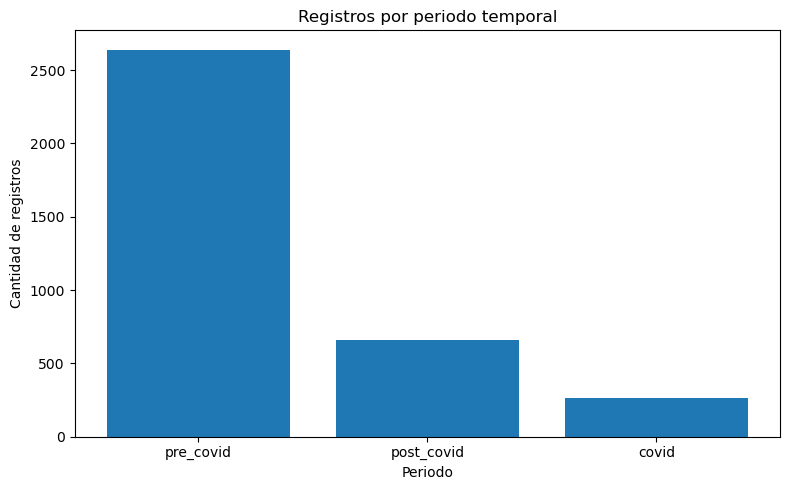

In [25]:
if "periodo" in df_processed.columns:
    registros_periodo = df_processed["periodo"].value_counts(dropna=False).reset_index()
    registros_periodo.columns = ["periodo", "registros"]

    display(registros_periodo)

    plt.figure(figsize=(8, 5))
    plt.bar(registros_periodo["periodo"].astype(str), registros_periodo["registros"])
    plt.title("Registros por periodo temporal")
    plt.xlabel("Periodo")
    plt.ylabel("Cantidad de registros")
    plt.tight_layout()
    plt.show()
else:
    print("No existe columna periodo.")

## Visualización de control: penetración promedio por región

Esta visualización permite verificar que las variables transformadas siguen siendo útiles para análisis exploratorios posteriores.

,region,gym_penetration_rate
2,Europe,0.113839
4,Oceania,0.098022
3,North America,0.088760
5,South America,0.055014
1,Asia,0.050762
0,Africa,0.013010


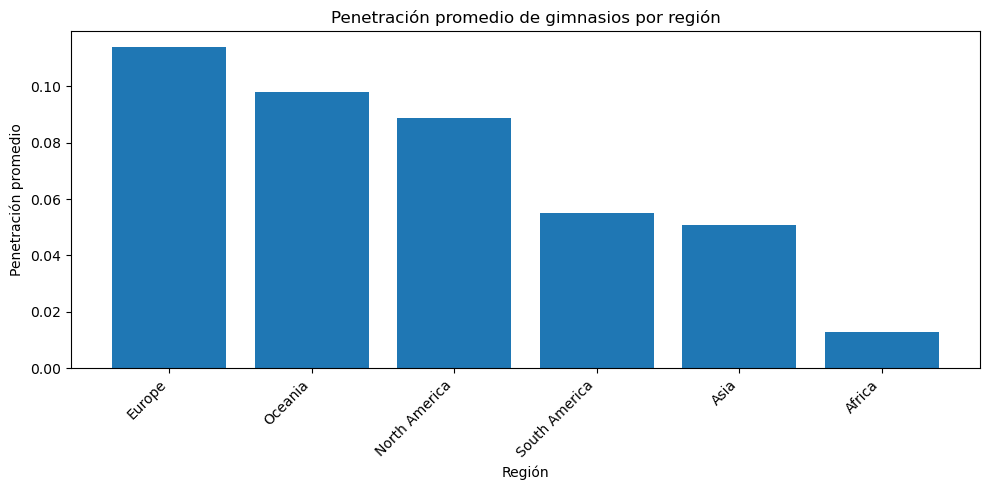

In [26]:
if {"region", "gym_penetration_rate"}.issubset(df_processed.columns):
    penetracion_region = (
        df_processed.groupby("region", as_index=False)["gym_penetration_rate"]
        .mean()
        .sort_values("gym_penetration_rate", ascending=False)
    )

    display(penetracion_region)

    plt.figure(figsize=(10, 5))
    plt.bar(penetracion_region["region"].astype(str), penetracion_region["gym_penetration_rate"])
    plt.title("Penetración promedio de gimnasios por región")
    plt.xlabel("Región")
    plt.ylabel("Penetración promedio")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No existen columnas requeridas.")

## Exportación del dataset procesado

Se guarda el dataset procesado en la carpeta `data/processed/`.

Esta salida será utilizada en fases posteriores para análisis exploratorio, visualización avanzada o modelación.

In [27]:
asegurar_directorio(PROCESSED_DIR)

df_processed.to_csv(PROCESSED_DATA_PATH, index=False, encoding="utf-8")

print("Dataset procesado exportado correctamente.")
print("Ruta:", PROCESSED_DATA_PATH)
print("Filas exportadas:", df_processed.shape[0])
print("Columnas exportadas:", df_processed.shape[1])

Dataset procesado exportado correctamente.
Ruta: ..\data\processed\gym_data_processed.csv
Filas exportadas: 3564
Columnas exportadas: 27


## Verificación del archivo exportado

Se vuelve a cargar el archivo exportado para confirmar que fue escrito correctamente.

In [28]:
validar_existencia_archivo(PROCESSED_DATA_PATH)

df_verificacion = pd.read_csv(PROCESSED_DATA_PATH)

print("Archivo procesado verificado correctamente.")
print("Filas:", df_verificacion.shape[0])
print("Columnas:", df_verificacion.shape[1])

df_verificacion.head()

Archivo procesado verificado correctamente.
Filas: 3564
Columnas: 27


,country,year,region,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct,memberships_per_100k,gyms_per_100k,revenue_per_membership_usd,periodo,gym_memberships_norm,total_health_club_revenue_usd_norm,number_of_gyms_norm,gdp_per_capita_usd_norm,population_total_norm,average_membership_cost_usd_norm,memberships_per_100k_norm,gyms_per_100k_norm,revenue_per_membership_usd_norm
0,Angola,2000,Africa,95521.0,0.3873,5731259.0,204.0,0.0059,0.5051,0.0470,563.7338,16194869.0,5.0,0.2219,589.822616,1.259658,59.999990,pre_covid,0.000909,0.000066,0.003230,0.003299,0.011038,0.0,0.012043,0.034128,0.000001
1,Angola,2001,Africa,103840.0,0.3939,6230372.0,222.0,0.0062,0.5172,0.0496,533.5862,16747208.0,5.0,0.2192,620.043651,1.325594,59.999730,pre_covid,0.000990,0.000071,0.003519,0.003080,0.011419,0.0,0.013051,0.036453,0.000001
2,Angola,2002,Africa,121093.0,0.4003,7265583.0,249.0,0.0070,0.5289,0.0522,999.0659,17327699.0,5.0,0.2164,698.840625,1.437006,60.000025,pre_covid,0.001158,0.000084,0.003953,0.006461,0.011819,0.0,0.015678,0.040381,0.000001
3,Angola,2003,Africa,142783.0,0.4065,8566966.0,281.0,0.0080,0.5400,0.0548,1133.6633,17943712.0,5.0,0.2137,795.727216,1.566008,59.999902,pre_covid,0.001369,0.000099,0.004467,0.007438,0.012243,0.0,0.018908,0.044930,0.000001
4,Angola,2004,Africa,179615.0,0.4124,10776918.0,325.0,0.0097,0.5504,0.0574,1451.4712,18600423.0,5.0,0.2110,965.650082,1.747272,60.000100,pre_covid,0.001728,0.000125,0.005174,0.009747,0.012696,0.0,0.024573,0.051321,0.000001


## Bitácora de transformaciones aplicadas

| Etapa | Acción | Justificación |
|---|---|---|
| Carga | Lectura de `clean_gym_data.csv` desde `data/raw/` | Mantener fuente original trazable. |
| Copia de trabajo | Creación de `df_work` | Evitar modificar directamente el dataset original. |
| Columnas | Validación contra lista esperada | Asegurar estructura compatible con el proyecto. |
| Nombres | Estandarización de nombres de columnas | Evitar errores por espacios o diferencias de formato. |
| Tipos | Casting de columnas numéricas y categóricas | Asegurar consistencia para cálculos y agrupaciones. |
| Duplicados | Eliminación de duplicados exactos | Evitar conteos y estadísticas distorsionadas. |
| Nulos | Tratamiento conservador por tipo de variable | Mantener continuidad del dataset bajo reglas explícitas. |
| Rangos | Validación de tasas, porcentajes y valores no negativos | Detectar inconsistencias técnicas. |
| Variables derivadas | Creación de métricas por 100.000 habitantes y periodo | Facilitar comparabilidad y análisis temporal. |
| Normalización | Creación de columnas `_norm` | Permitir comparaciones en escala común. |
| Exportación | Guardado en `data/processed/` | Separar datos originales de datos procesados. |

## Validaciones recomendadas en GitHub Actions

Para integrar este notebook al flujo de CI/CD, se recomienda agregar una validación que ejecute:

```bash
jupyter nbconvert --to notebook --execute F2_Limpieza_Transformacion.ipynb --output F2_Limpieza_Transformacion_ejecutado.ipynb --ExecutePreprocessor.timeout=300 --ExecutePreprocessor.kernel_name=python3
```

También se recomienda validar la existencia del archivo procesado:

```bash
test -f data/processed/gym_data_processed.csv || echo "El archivo procesado se genera al ejecutar el notebook F2"
```

El objetivo es comprobar que el pipeline puede ejecutarse en un entorno limpio.

## Riesgos y decisiones metodológicas

### Riesgos identificados

- El dataset puede contener datos estimados o modelados.
- Algunas variables pueden tener escalas muy distintas.
- Las relaciones entre variables no deben interpretarse como causalidad.
- La comparación entre países puede verse afectada por población, economía y cobertura de datos.
- La normalización facilita comparación, pero no reemplaza el análisis estadístico posterior.
- El tratamiento de nulos por mediana es una decisión inicial y debe reevaluarse si aparecen nulos relevantes.

### Decisiones metodológicas

- No se modifica el archivo original en `data/raw/`.
- Se trabaja sobre una copia del DataFrame.
- Se documentan todas las transformaciones.
- Se exporta una versión procesada a `data/processed/`.
- Se conservan las variables originales y se agregan variables derivadas.
- Se evita eliminar información sin justificación explícita.

## Conclusión técnica de Fase 2

El notebook de Fase 2 implementa un pipeline reproducible de obtención, limpieza, transformación y validación del dataset. Se incorporan funciones modulares, estructuras de control, verificaciones técnicas y exportación de un archivo procesado para fases posteriores.

El resultado principal es la generación de una versión procesada del dataset:

```text
data/processed/gym_data_processed.csv
```

Esta versión mantiene trazabilidad con el archivo original y agrega transformaciones útiles para futuros análisis. La documentación integrada en Markdown permite comprender cada decisión técnica y metodológica aplicada durante el proceso.

## Referencias

GitHub Docs. (2024). *GitHub Actions documentation*. https://docs.github.com/actions

GitHub Docs. (2024). *GitHub Models documentation*. https://docs.github.com/github-models

McKinney, W. (2022). *Python for Data Analysis: Data Wrangling with pandas, NumPy, and Jupyter* (3rd ed.). O'Reilly Media.

Mishra, A. (2026). *World Gym & Fitness Trends 2000-2026* [Conjunto de datos]. Kaggle.

pandas development team. (2024). *pandas documentation*. https://pandas.pydata.org/docs/

Project Jupyter. (2024). *Jupyter documentation*. https://docs.jupyter.org/

Python Software Foundation. (2024). *Python documentation*. https://docs.python.org/3/

Material docente del curso. (2026). *Guía técnica de Fase 2: Obtención, limpieza y transformación de datos*. Plataforma institucional.

Material docente del curso. (2026). *Rúbrica de Evaluación Sumativa 2*. Plataforma institucional.